# Example: Bandit Elasticity Learning

In this example, we apply the **epsilon-greedy multi-armed bandit** to learn the best CES elasticity $\eta$ per sentiment regime. Instead of using the Session 2 heuristic $\eta(\lambda_t) = \eta_{\min} + (\eta_{\max} - \eta_{\min})/(1 + |\lambda_t|)$, we let the bandit train across a path ensemble and discover which $\eta$ value produces the highest utility in bearish, neutral, and bullish conditions, then deploy on held-out paths.

The Session 2 heuristic baked the elasticity-vs-sentiment relationship into a hand-designed formula: $\eta$ falls smoothly with $|\lambda_t|$ and is symmetric in bull and bear. This example removes that prior and lets a bandit pick the best elasticity per regime from reward feedback alone. The deployed policy is then compared not just to the heuristic but to the best *flat* $\eta$ on the held-out distribution: a flat oracle that any regime-aware policy must beat to justify its per-regime structure.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
> * __Explain regime-specific elasticity learning under multi-path training:__ Describe how a per-regime bandit trained across many paths populates all three regime bins and discovers elasticity values that a fixed sentiment-symmetric formula cannot adapt to. Read per-regime arm pulls and means to interpret what the bandit learned and how confident it is in each regime.
> * __Interpret distributional evidence on elasticity selection against a flat oracle:__ Compare the bandit-learned regime-aware policy, the Session 2 heuristic, and the best flat $\eta$ on the held-out path ensemble with the same bias treatment, so distributional differences in median wealth, drawdown, and risk-adjusted growth are attributable to the elasticity-selection method itself.
> * __Assess whether regime-awareness beats a well-chosen constant:__ Use the win rate and median paired-excess between the bandit-learned regime-aware policy and the best flat $\eta$ to judge whether per-regime structure produces a real edge beyond what any constant policy could achieve. Read the paired distribution to separate genuine improvement from sampling noise on a fixed-seed ensemble.

Let's see if a learner can beat a well-chosen constant, and read the answer honestly when it does not: a clean negative result is itself the lesson when the reward we optimize is not the objective we ultimately care about.

___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants
In the section below, we set some constants that will be used throughout the notebook. We can modify these constants to explore different scenarios and allocations.

See the comments in the code for more details on each constant, its purpose, units, etc.

In [2]:
# Eta-bandit configuration
B₀ = 10_000.0                                # starting budget (USD)
Δt = 1.0 / 252.0                             # trading-day step (years)
L_short = 21                                 # short EMA window (days) for the sentiment crossover
L_long = 63                                  # long EMA window (days) for the sentiment crossover
L_growth = 10                                # EMA window (days) for smoothed market growth rate
GAIN = 10.0                                  # gain constant G for the λ sentiment signal (dimensionless)
offset = L_short + L_long                    # warmup offset before trading begins (days)
SCENARIO_SEED = 2026                         # RNG seed for the hybrid-SIM scenario (locked across Examples 1-2)
ETA_GRID = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]    # discrete CES elasticity arms (one bandit arm per η value)
BANDIT_TRAINING_PATHS = 50                   # paths used to train the bandit; remaining paths are held out for deployment
BANDIT_ALPHA = 0.1                           # constant learning rate for bandit arm-mean updates
LAMBDA_THRESHOLD = 0.5                       # |λ| boundary partitioning sentiment into bear/neutral/bull bins
TRIGGER_MAX_DRAWDOWN = 0.15                  # drawdown trigger threshold (de-risks to cash, fraction)
TRIGGER_MAX_TURNOVER = 0.50                  # max fraction of wealth traded per rebalance
ETA_BOUNDS = (0.5, 5.0)                      # adaptive-η bounds for the heuristic baseline (η_min, η_max)
ALLOCATION_EPSILON = 0.1                     # ε floor for non-preferred assets in the Cobb-Douglas allocator
ENGINE_PRIOR_CCGR_PCT = 8.0                  # bias-correction anchor (% /yr); matches Session 2 + EWLS notebook

8.0

Load the same Session 1 artifacts and regenerate the same forward path ensemble used in Example 1 (EWLS Engine Replay). The deterministic seed ensures identical paths.

In the code block below, we load the Session 1 minimum-variance pack, build the SIM-parameter dictionary keyed by ticker, instantiate the [`MyMarketSurrogateModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyMarketSurrogateModel) and [`MyPortfolioSurrogateModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyPortfolioSurrogateModel) calibrated in Session 1, and call [`generate_hybrid_scenario(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario) with the locked seed to produce the forward path ensemble.

The cell returns:

* `my_tickers::Vector{String}`: Session 1 ticker universe (same order as `allocation_weights`).
* `sim_estimates::Vector{MySIMParameterEstimate}`: per-ticker SIM fits with α, β, σ_ε.
* `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`: allocator-adapter view of `sim_estimates`, keyed by ticker.
* `g_f::Float64`: continuously compounded annual risk-free rate (1/yr); used to discount terminal wealth into NPV against the risk-free baseline.
* [`market_model::MyMarketSurrogateModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyMarketSurrogateModel): 50-state generative model market surrogate fit to SPY.
* [`portfolio::MyPortfolioSurrogateModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyPortfolioSurrogateModel): per-ticker generative marginals and Student-t copula for path composition.
* `calib::Dict{String,Any}`: full SIM calibration dict (source of truth for α, β, σ_ε, and bootstrap SEs).
* `start_prices::Dict{String,Float64}`: per-ticker starting prices for forward scenarios.
* `N::Int`: number of tickers in the universe.
* `scenario::MyBacktestScenario`: hybrid forward path ensemble (seed-locked for reproducibility across Examples 1-2).

In [3]:
(; my_tickers, sim_estimates, sim_params, g_f,
   market_model, portfolio, calib, start_prices, N, scenario) = let
    # --- Step 1: Load S1 artifacts ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers    = minvar["my_tickers"]::Vector{String};
    sim_estimates = minvar["sim_estimates"];
    g_f           = haskey(minvar, "g_f") ? Float64(minvar["g_f"]) : Float64(minvar["r_f"]);
    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e in sim_estimates
    );

    # --- Step 2: Surrogates and scenario ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    snap        = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t in my_tickers);

    # --- Step 3: Dimensions ---
    N         = length(my_tickers);
    n_trading_days   = 252;
    T_total          = offset + n_trading_days;

    # --- Step 4: Regenerate scenario (same seed as Example 1) ---
    Random.seed!(SCENARIO_SEED);
    scenario = generate_hybrid_scenario(
        market_model, portfolio, calib, my_tickers;
        n_paths = 500, n_steps = T_total,
        start_prices = start_prices, label = "S3 Eta-Bandit", seed = SCENARIO_SEED);

    println("Loaded $(N) tickers, generated $(scenario.n_paths)-path scenario")
    (my_tickers = my_tickers, sim_estimates = sim_estimates, sim_params = sim_params,
     g_f = g_f, market_model = market_model, portfolio = portfolio,
     calib = calib, start_prices = start_prices, N = N, scenario = scenario)
end;

Loaded 20 tickers, generated 500-path scenario


___
## Task 1: Train the Elasticity Bandit Across a Path Ensemble
In this task, we train the elasticity bandit across the first `BANDIT_TRAINING_PATHS = 50` paths from the scenario, accumulating per-regime arm pulls in a single shared state. The remaining 450 paths are held out for deployment in Task 2. The bandit walks each training path in sequence, classifying every step into bearish / neutral / bullish via $|\lambda_t| \gtrless \theta$, and updates the arm mean for the active regime alone via [`solve_eta_bandit_multipath(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.solve_eta_bandit_multipath) on a [`MyEtaBanditModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyEtaBanditModel) instance.

Multi-path training matters here because a single 252-day path rarely visits all three regimes: most paths spend the bulk of their steps in the neutral bin and never (or rarely) cross into bearish or bullish. Single-path training therefore leaves the bear and bull arms untrained and the bandit's deployed policy in those regimes degrades to a default. Walking 50 paths populates all three bins with thousands of pulls and lets the bandit actually localize a per-regime optimum.

> __What is the reward when we pull an $\eta$ arm at time $t$?__
>
> The reward function [`eta_bandit_world(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.eta_bandit_world) reads the current sentiment $\lambda_t$ and smoothed market growth $\bar{g}_{m,t}$, computes the Cobb-Douglas preference weights $\gamma$ (independent of $\eta$), solves the CES allocator at the chosen $\eta$ to obtain a share vector and cash, and then computes the *realized one-period log-wealth growth* $\log(W_{t+1}/W_t)$ of holding that allocation through the next step. The reward is therefore a small dimensionless number on the order of $10^{-3}$ to $10^{-2}$ per day, comparable across $\eta$ values and aligned with the deployment metric (terminal wealth). The bandit is learning which $\eta$ produces the highest realized log-wealth growth in each regime, which is exactly the objective Task 2 evaluates on held-out paths.

With the reward defined, we can read the diagnostics the bandit emits.

> __What should we see?__
>
> All three regime bins should accumulate non-zero pull counts now that training spans many paths, and the per-regime arm-mean bar charts should show a clear argmax in each bin rather than a flat untrained profile. The reward trace is the concatenated log-wealth growth across the training tape; individual rewards are noisy (single-day moves) but the per-arm running average converges as samples accumulate.

The code block below returns `bandit_result::`[`MyEtaBanditResult`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyEtaBanditResult) carrying the per-regime arm means, pull counts, reward trace, and best-elasticity map.

In [4]:
bandit_result = let
    # --- Step 1: Build training contexts (first BANDIT_TRAINING_PATHS paths) ---
    M = BANDIT_TRAINING_PATHS;
    T_total = scenario.n_steps;
    contexts = MyRebalancingContextModel[];
    lambda_per_path = Vector{Float64}[];
    time_indices_per_path = Vector{Int}[];

    for p in 1:M
        mkt = scenario.market_paths[p, :];
        pmatrix = zeros(T_total, N + 1);
        pmatrix[:, 1] = 1:T_total;
        for k in 1:N
            pmatrix[:, k + 1] = scenario.price_paths[p, :, k];
        end

        ema_s = compute_ema(mkt; window = L_short);
        ema_l = compute_ema(mkt; window = L_long);
        λ_p = compute_lambda(ema_s, ema_l; G = GAIN);
        λ_p[1:offset] .= 0.0;
        gm_raw = compute_market_growth(mkt; Δt = Δt);
        gm_ema = compute_ema(gm_raw; window = L_growth);

        ctx_p = build(MyRebalancingContextModel, (
            B = B₀, tickers = my_tickers, marketdata = pmatrix,
            marketfactor = gm_ema, sim_parameters = sim_params,
            lambda = 0.0, Δt = Δt, epsilon = ALLOCATION_EPSILON
        ));

        push!(contexts, ctx_p);
        push!(lambda_per_path, λ_p);
        push!(time_indices_per_path, collect((offset + 1):(T_total - 1)));
    end

    # --- Step 2: Build and run multi-path eta-bandit ---
    Random.seed!(SCENARIO_SEED);
    bandit = build(MyEtaBanditModel, (
        eta_grid = ETA_GRID, n_iterations = M * (T_total - offset),
        alpha = BANDIT_ALPHA, lambda_threshold = LAMBDA_THRESHOLD
    ));
    bandit_result = solve_eta_bandit_multipath(bandit, contexts, lambda_per_path, time_indices_per_path);

    # --- Step 3: Build per-regime results DataFrame (rows = regime, columns = best η, total pulls, per-arm μ̂) ---
    regime_list = [:bearish, :neutral, :bullish];
    regime_df = DataFrame(
        "Regime"      => string.(regime_list),
        "Best η"      => [bandit_result.best_eta_per_regime[r] for r in regime_list],
        "Total pulls" => [sum(bandit_result.arm_counts_per_regime[r]) for r in regime_list],
    );
    for (i, eta_val) in enumerate(ETA_GRID)
        regime_df[!, "μ̂(η=$(eta_val))"] = [round(bandit_result.arm_means_per_regime[r][i], digits = 3) for r in regime_list];
    end
    println("Eta-bandit results across $(M) training paths:")
    pretty_table(regime_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    bandit_result
end

Eta-bandit results across 50 training paths:
 --------- --------- ------------- ---------- ---------- ---------- ---------- ---------- ----------
   Regime    Best η   Total pulls   μ̂(η=0.5)   μ̂(η=1.0)   μ̂(η=1.5)   μ̂(η=2.0)   μ̂(η=3.0)   μ̂(η=5.0) 
   String   Float64         Int64    Float64    Float64    Float64    Float64    Float64    Float64 
 --------- --------- ------------- ---------- ---------- ---------- ---------- ---------- ----------
  bearish       1.5           155      0.001     -0.002      0.005      0.002      0.001      0.005
  neutral       0.5         11700      0.001        0.0       -0.0     -0.001     -0.001     -0.001
  bullish       3.0           695     -0.003     -0.001        0.0        0.0      0.001       -0.0
 --------- --------- ------------- ---------- ---------- ---------- ---------- ---------- ----------


MyEtaBanditResult(Dict(:neutral => 0.5, :bullish => 3.0, :bearish => 1.5), Dict(:neutral => [0.0005329449782203073, 0.00018333461372264123, -0.0004395738098209676, -0.0005021048354223896, -0.0011475381020908224, -0.0007193947290429938], :bullish => [-0.003463885134641492, -0.000697560220627013, 0.00027710296157410294, 0.00020772866295833755, 0.0007452222868565325, -0.0004176475903976077], :bearish => [0.0014530307728476146, -0.0016712203877179918, 0.004727748402748501, 0.0015560586626235035, 0.001218239100514087, 0.004709995794703534]), Dict(:neutral => [2257, 1750, 2320, 2295, 1555, 1523], :bullish => [95, 99, 116, 176, 108, 101], :bearish => [18, 25, 19, 22, 37, 34]), [-0.00018611573286400284, 0.0009104202595648299, -0.001116104386148767, 0.0004957599410679499, -0.0013362174358938596, -0.00027923405550161383, 0.0005633668453423205, 0.027141559758935327, -0.004703278489033331, 0.01878772931149295  …  -0.0225073856811726, -0.012982407427903797, -0.0002669465547836636, -0.00392667931269

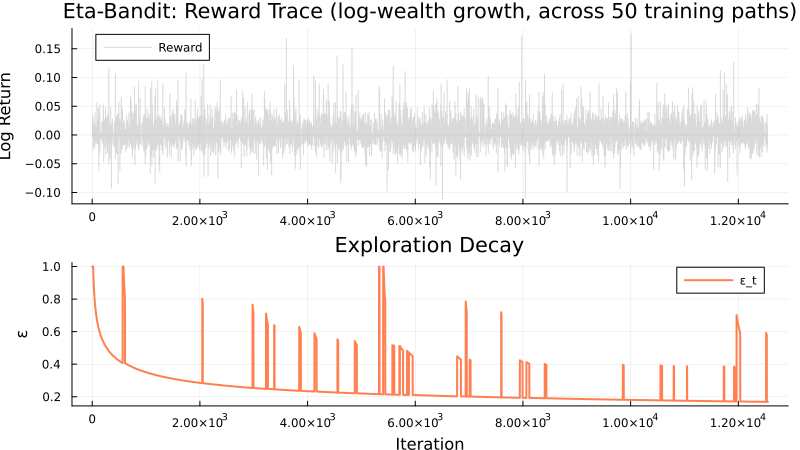

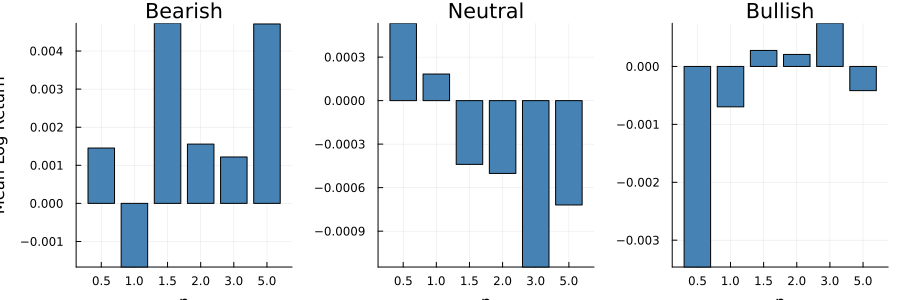

In [5]:
let
    # --- Panel 1: Reward trace (concatenated across training paths) ---
    p1 = plot(bandit_result.reward_history, label="Reward", alpha=0.3, color=:gray50,
        ylabel="Log Return", title="Eta-Bandit: Reward Trace (log-wealth growth, across $(BANDIT_TRAINING_PATHS) training paths)", size=(800, 250))

    # --- Panel 2: Exploration decay ---
    p2 = plot(bandit_result.exploration_history, label="ε_t", color=:coral, linewidth=2,
        ylabel="ε", title="Exploration Decay", xlabel="Iteration", size=(800, 200))

    display(plot(p1, p2, layout=grid(2,1, heights=[0.55, 0.45]), size=(800, 450)))

    # --- Panel 3: Per-regime arm means ---
    p3 = plot(layout=(1,3), size=(900, 300), title=["Bearish" "Neutral" "Bullish"])
    for (j, regime) in enumerate([:bearish, :neutral, :bullish])
        bar!(p3[j], string.(ETA_GRID), bandit_result.arm_means_per_regime[regime],
            label="", color=:steelblue, xlabel="η", ylabel=j==1 ? "Mean Log Return" : "")
    end
    display(p3)
end;

___
## Task 2: Deploy on Held-Out Paths Against a Flat-η Oracle
In this task, we deploy the bandit's learned $\eta$ map on the held-out paths $(M+1, \ldots, n_\text{paths})$ via [`backtest_eta_bandit(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_eta_bandit), run the Session 2 heuristic $\eta(\lambda)$ on the same held-out paths, and run a flat-$\eta$ sweep across all six values in the bandit's grid on the *training* paths to pick the best constant. We then deploy that training-selected best flat $\eta$ on held-out for evaluation. The flat oracle is the highest median terminal wealth a regime-blind constant policy can achieve when its $\eta$ is selected from the same data the bandit was trained on. The bandit's value-add is the gap between its deployed regime-aware policy and that flat oracle on held-out paths; if the gap is positive, the per-regime structure paid for itself, and if it is zero or negative, it did not.

> __Why select the flat oracle on training paths and not on held-out?__
>
> The bandit's learning is constrained to training paths, so the fair flat-policy comparison is also constrained to training paths. Selecting the flat oracle on held-out would give the constant policy a look-ahead advantage the bandit does not have, and would inflate the apparent flat-policy performance. Picking on training paths and evaluating on held-out keeps both algorithms honest. We print the full training-paths flat-$\eta$ sweep so the reader can see the curve the oracle picked from.

With the oracle defined, we can read what the scorecard tells us.

> __What should we see?__
>
> All three columns (bandit, heuristic, flat oracle) share the same held-out paths and the same bias treatment, so distributional differences in median wealth, drawdown, and Sharpe are attributable to the elasticity-selection method. The flat oracle is the floor any regime-aware policy must beat. If the bandit beats it, regime-awareness is worth the complexity at this training budget; if it ties or loses, the per-regime structure is not adding signal and the heuristic / flat constant is the right baseline to deploy.

The code block below returns `bandit_bt::`[`MyBacktestResult`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyBacktestResult), the bias-corrected per-path terminal-wealth, drawdown, and Sharpe arrays for the bandit-learned-elasticity engine across the held-out path ensemble.

In [6]:
bandit_bt = let
    # --- Step 0: Local bias-correction helper (mirrors the EWLS notebook) ---
    function _apply_bias(r::MyBacktestResult, bias_pct_per_yr::Float64, Δt::Float64)::MyBacktestResult
        n_t, n_p = size(r.wealth_paths);
        drag = exp.(-bias_pct_per_yr / 100.0 .* (0:(n_t-1)) .* Δt);
        Wc = r.wealth_paths .* drag;
        final_wealth_c  = Wc[end, :];
        max_drawdowns_c = zeros(n_p);
        sharpe_ratios_c = zeros(n_p);
        for p ∈ 1:n_p
            wealth = Wc[:, p];
            peak = accumulate(max, wealth);
            max_drawdowns_c[p] = maximum((peak .- wealth) ./ peak);
            vol = std(diff(wealth) ./ wealth[1:end-1]) * sqrt(252);
            mean_ret = (wealth[end] / wealth[1] - 1.0);
            sharpe_ratios_c[p] = vol > 1e-6 ? mean_ret / vol : 0.0;
        end
        rc = MyBacktestResult();
        rc.scenario_label = r.scenario_label;
        rc.strategy_label = r.strategy_label * " [bias-corrected $(round(bias_pct_per_yr, digits=2))pp/yr]";
        rc.final_wealth   = final_wealth_c;
        rc.max_drawdowns  = max_drawdowns_c;
        rc.sharpe_ratios  = sharpe_ratios_c;
        rc.wealth_paths   = Wc;
        return rc;
    end

    # --- Step 1: Single-path engine helper (returns wealth series for one path under one strategy) ---
    function _run_engine_path(p::Int, allocator_args::NamedTuple)::Vector{Float64}
        mkt = scenario.market_paths[p, :];
        ema_s = compute_ema(mkt; window = L_short);
        ema_l = compute_ema(mkt; window = L_long);
        λ_p = compute_lambda(ema_s, ema_l; G = GAIN);
        λ_p[1:offset] .= 0.0;
        gm_raw = compute_market_growth(mkt; Δt = Δt);
        gm_e = compute_ema(gm_raw; window = L_growth);

        pmatrix = zeros(scenario.n_steps, N + 1);
        pmatrix[:, 1] = 1:scenario.n_steps;
        for k in 1:N
            pmatrix[:, k + 1] = scenario.price_paths[p, :, k];
        end

        ctx = build(MyRebalancingContextModel, (
            B = B₀, tickers = my_tickers, marketdata = pmatrix,
            marketfactor = gm_e, sim_parameters = sim_params,
            lambda = 0.0, Δt = Δt, epsilon = ALLOCATION_EPSILON
        ));
        n_trading = scenario.n_steps - offset;
        rules = build(MyTriggerRules, (
            max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER,
            rebalance_schedule = ones(Int, n_trading)
        ));
        results = run_rebalancing_engine(ctx, rules, λ_p; offset = offset, allocator = :ces, allocator_args...);
        return compute_wealth_series(results, pmatrix, my_tickers; offset = offset);
    end

    # --- Step 2: Training-paths flat-η sweep to select the flat oracle ---
    M = BANDIT_TRAINING_PATHS;
    train_indices = 1:M;
    train_med_ww0 = Dict{Float64,Float64}();
    for η_val in ETA_GRID
        fw_train = zeros(M);
        for p in train_indices
            w = _run_engine_path(p, (adaptive_eta = false, eta = η_val));
            fw_train[p] = w[end];
        end
        train_med_ww0[η_val] = median(fw_train) / B₀;
    end
    best_flat_eta = argmax(η -> train_med_ww0[η], ETA_GRID);
    println("Flat-η median W/W₀ on training paths ($(M) paths):");
    for η_val in ETA_GRID
        flag = η_val == best_flat_eta ? "  ← oracle" : "";
        println("  η = $(η_val):  $(round(train_med_ww0[η_val], digits=3))$(flag)");
    end

    # --- Step 3: Held-out deployment of bandit (full scenario via backtest_eta_bandit, sliced to held-out) ---
    held_indices = collect((M+1):scenario.n_paths);
    n_held = length(held_indices);
    n_trading = scenario.n_steps - offset;

    eta_map = bandit_result.best_eta_per_regime;
    bandit_full = backtest_eta_bandit(scenario, my_tickers, sim_params, eta_map;
        B₀ = B₀, offset = offset, L_short = L_short, L_long = L_long,
        GAIN = GAIN, L_growth = L_growth, lambda_threshold = LAMBDA_THRESHOLD);

    bandit_bt_raw = MyBacktestResult();
    bandit_bt_raw.scenario_label = bandit_full.scenario_label;
    bandit_bt_raw.strategy_label = "Bandit-η raw";
    bandit_bt_raw.final_wealth   = bandit_full.final_wealth[held_indices];
    bandit_bt_raw.max_drawdowns  = bandit_full.max_drawdowns[held_indices];
    bandit_bt_raw.sharpe_ratios  = bandit_full.sharpe_ratios[held_indices];
    bandit_bt_raw.wealth_paths   = bandit_full.wealth_paths[:, held_indices];

    # --- Step 4: Held-out deployment of heuristic and flat oracle (per-path inline loop) ---
    heur_w  = zeros(n_trading + 1, n_held); heur_fw  = zeros(n_held); heur_dd  = zeros(n_held); heur_sr  = zeros(n_held);
    flat_w  = zeros(n_trading + 1, n_held); flat_fw  = zeros(n_held); flat_dd  = zeros(n_held); flat_sr  = zeros(n_held);
    for (i, p) in enumerate(held_indices)
        w_h = _run_engine_path(p, (adaptive_eta = true, eta_bounds = ETA_BOUNDS));
        heur_w[:, i] .= w_h;
        heur_fw[i] = w_h[end];
        ret_h = diff(w_h) ./ w_h[1:end-1];
        pk_h = accumulate(max, w_h);
        heur_dd[i] = maximum((pk_h .- w_h) ./ pk_h);
        vol_h = std(ret_h) * sqrt(252);
        heur_sr[i] = vol_h > 0 ? (w_h[end]/w_h[1] - 1.0) / vol_h : 0.0;

        w_f = _run_engine_path(p, (adaptive_eta = false, eta = best_flat_eta));
        flat_w[:, i] .= w_f;
        flat_fw[i] = w_f[end];
        ret_f = diff(w_f) ./ w_f[1:end-1];
        pk_f = accumulate(max, w_f);
        flat_dd[i] = maximum((pk_f .- w_f) ./ pk_f);
        vol_f = std(ret_f) * sqrt(252);
        flat_sr[i] = vol_f > 0 ? (w_f[end]/w_f[1] - 1.0) / vol_f : 0.0;
    end

    heur_bt_raw = MyBacktestResult();
    heur_bt_raw.scenario_label = scenario.label;
    heur_bt_raw.strategy_label = "Heuristic-η raw";
    heur_bt_raw.final_wealth   = heur_fw;
    heur_bt_raw.max_drawdowns  = heur_dd;
    heur_bt_raw.sharpe_ratios  = heur_sr;
    heur_bt_raw.wealth_paths   = heur_w;

    flat_bt_raw = MyBacktestResult();
    flat_bt_raw.scenario_label = scenario.label;
    flat_bt_raw.strategy_label = "Flat η=$(best_flat_eta) raw";
    flat_bt_raw.final_wealth   = flat_fw;
    flat_bt_raw.max_drawdowns  = flat_dd;
    flat_bt_raw.sharpe_ratios  = flat_sr;
    flat_bt_raw.wealth_paths   = flat_w;

    # --- Step 5: Bias correction anchored to ENGINE_PRIOR_CCGR_PCT (same anchor as EWLS notebook) ---
    bandit_raw_med_ccgr = let
        gs = Float64[];
        for p ∈ 1:n_held
            w = bandit_bt_raw.wealth_paths[:, p];
            push!(gs, log(w[end] / w[1]) / ((length(w) - 1) * Δt) * 100);
        end
        median(gs)
    end;
    bias_pct_per_yr = bandit_raw_med_ccgr - ENGINE_PRIOR_CCGR_PCT;
    println("\n  Bandit-η raw median CCGR (held-out): $(round(bandit_raw_med_ccgr, digits=2)) %/yr");
    println("  ENGINE_PRIOR_CCGR_PCT:               $(ENGINE_PRIOR_CCGR_PCT) %/yr");
    println("  Bias correction drag:                $(round(bias_pct_per_yr, digits=2)) pp/yr (applied to all three daily-rebalanced arms)");

    bandit_bt_c = _apply_bias(bandit_bt_raw, bias_pct_per_yr, Δt);
    heur_bt_c   = _apply_bias(heur_bt_raw,   bias_pct_per_yr, Δt);
    flat_bt_c   = _apply_bias(flat_bt_raw,   bias_pct_per_yr, Δt);

    # --- Step 6: NPV against the continuously-compounded risk-free baseline ---
    T_active   = (scenario.n_steps - offset) * Δt;
    discount   = exp(-g_f * T_active);
    bandit_npv = bandit_bt_c.final_wealth .* discount .- B₀;
    heur_npv   = heur_bt_c.final_wealth   .* discount .- B₀;
    flat_npv   = flat_bt_c.final_wealth   .* discount .- B₀;

    # --- Step 7: Build the distributional comparison DataFrame ---
    scorecard_df = DataFrame(
        "Metric" => ["Median W/W₀", "Median Max DD (%)", "Median Sharpe",
                     "Median NPV (\$)", "Median NPV (% of B₀)", "P[NPV<0] (%)"],
        "Bandit-η" => Any[
            round(median(bandit_bt_c.final_wealth) / B₀, digits = 3),
            round(median(bandit_bt_c.max_drawdowns) * 100, digits = 1),
            round(median(bandit_bt_c.sharpe_ratios), digits = 3),
            round(median(bandit_npv),              digits = 0),
            round(median(bandit_npv) / B₀ * 100,   digits = 2),
            round(mean(bandit_npv .< 0) * 100,     digits = 1),
        ],
        "Heuristic-η" => Any[
            round(median(heur_bt_c.final_wealth) / B₀, digits = 3),
            round(median(heur_bt_c.max_drawdowns) * 100, digits = 1),
            round(median(heur_bt_c.sharpe_ratios), digits = 3),
            round(median(heur_npv),              digits = 0),
            round(median(heur_npv) / B₀ * 100,   digits = 2),
            round(mean(heur_npv .< 0) * 100,     digits = 1),
        ],
        "Flat η=$(best_flat_eta) (oracle)" => Any[
            round(median(flat_bt_c.final_wealth) / B₀, digits = 3),
            round(median(flat_bt_c.max_drawdowns) * 100, digits = 1),
            round(median(flat_bt_c.sharpe_ratios), digits = 3),
            round(median(flat_npv),              digits = 0),
            round(median(flat_npv) / B₀ * 100,   digits = 2),
            round(mean(flat_npv .< 0) * 100,     digits = 1),
        ],
    );
    println("\nCES η strategies on held-out paths ($(n_held) paths, bias-corrected to anchor=$(ENGINE_PRIOR_CCGR_PCT) %/yr):")
    pretty_table(scorecard_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Step 8: Save the hand-off (NPV arrays + learned policy + flat oracle) ---
    save_results(joinpath(_PATH_TO_DATA, "eta-bandit-results.jld2"), Dict(
        "bandit_final_wealth"   => bandit_bt_c.final_wealth,
        "bandit_max_dd"         => bandit_bt_c.max_drawdowns,
        "bandit_sharpe"         => bandit_bt_c.sharpe_ratios,
        "bandit_npv"            => bandit_npv,
        "heur_final_wealth"     => heur_bt_c.final_wealth,
        "heur_max_dd"           => heur_bt_c.max_drawdowns,
        "heur_sharpe"           => heur_bt_c.sharpe_ratios,
        "heur_npv"              => heur_npv,
        "flat_final_wealth"     => flat_bt_c.final_wealth,
        "flat_max_dd"           => flat_bt_c.max_drawdowns,
        "flat_sharpe"           => flat_bt_c.sharpe_ratios,
        "flat_npv"              => flat_npv,
        "best_eta_per_regime"   => bandit_result.best_eta_per_regime,
        "best_flat_eta"         => best_flat_eta,
        "train_med_ww0_per_eta" => train_med_ww0,
        "bias_pct_per_yr"       => bias_pct_per_yr,
        "g_f"                   => g_f,
        "T_active"              => T_active,
        "n_training_paths"      => M,
        "n_held_paths"          => n_held,
    ));
    println("Saved to eta-bandit-results.jld2")
    bandit_bt_c
end;

Flat-η median W/W₀ on training paths (50 paths):
  η = 0.5:  1.73
  η = 1.0:  1.818
  η = 1.5:  1.898  ← oracle
  η = 2.0:  1.896
  η = 3.0:  1.828
  η = 5.0:  1.724

  Bandit-η raw median CCGR (held-out): 50.54 %/yr
  ENGINE_PRIOR_CCGR_PCT:               8.0 %/yr
  Bias correction drag:                42.54 pp/yr (applied to all three daily-rebalanced arms)

CES η strategies on held-out paths (450 paths, bias-corrected to anchor=8.0 %/yr):
 ---------------------- ---------- ------------- ---------------------
                Metric   Bandit-η   Heuristic-η   Flat η=1.5 (oracle) 
                String        Any           Any                   Any 
 ---------------------- ---------- ------------- ---------------------
           Median W/W₀      1.083         1.059                 1.171
     Median Max DD (%)       16.6          21.7                  15.7
         Median Sharpe      0.394         0.234                 0.733
        Median NPV ($)      356.0         119.0              

___
## Task 3: Paired Excess: Bandit vs Flat Oracle
In this task, we compare the bandit's per-regime policy to the flat oracle on a paired, per-path basis. For each held-out path we compute $W_T^\text{bandit} - W_T^\text{flat}$, and from the distribution of these per-path differences we report the win rate, the median excess, and the mean excess. A positive median excess on a non-trivial fraction of paths is the cleanest test that regime-awareness is contributing real signal beyond what the best constant policy could achieve at the same training budget.

> __What should we see, and what if the bandit loses?__
>
> A win rate above 50 % is necessary but not sufficient: a bandit that wins by a hair on most paths but loses badly on a few would still have a positive win rate and a negative mean. Read the median first because it is robust to tail blow-ups, then check that the mean is in the same direction. A right-shifted histogram with positive median says regime-awareness is paying for itself; a histogram that straddles zero says the bandit and the flat oracle are statistically indistinguishable; a left-shifted histogram with negative median says the per-regime policy is *actively worse* than a well-chosen constant on held-out wealth. A left-shifted result is not a failure of the bandit framework, it is a teachable finding: the bandit's reward is the realized one-period log-wealth growth at the chosen $\eta$, but deployment is scored on terminal wealth across many compounding steps, and a per-regime $\eta$ that wins on per-step expected log return can still over-concentrate the allocation in ways that hurt long-horizon compounding. The right response when this happens is to either change the reward (variance-penalized or multi-step log-wealth) or accept that the flat constant is the deployable policy at this training budget; either way the negative result has separated a real algorithmic shortcoming from a methodological lesson.

In the code block below, we load the saved bandit and flat-oracle terminal-wealth arrays, compute the paired excess and win rate, and plot the histogram with a dashed zero line and a coral median marker.

Paired excess (Bandit-η − Flat η=1.5):
 ------------------------- ---------
                   Metric     Value 
                   String   Float64 
 ------------------------- ---------
             Win rate (%)      14.0
        Median excess ($)    -687.0
  Median excess (% of W₀)     -6.87
          Mean excess ($)    -776.0
    Mean excess (% of W₀)     -7.76
 ------------------------- ---------


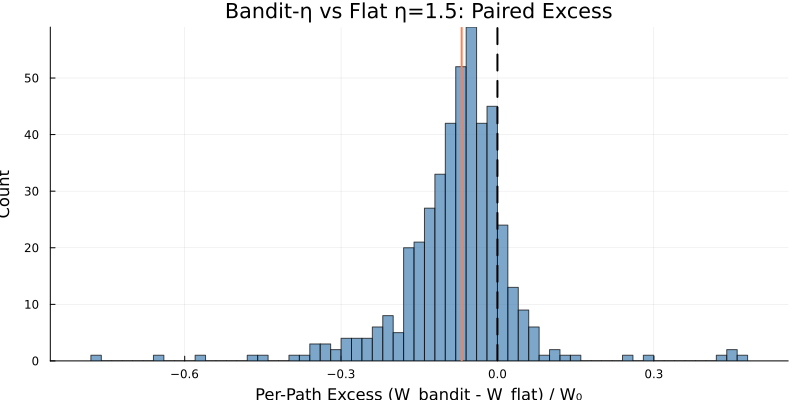

In [7]:
let
    # --- Step 1: Load bandit and flat-oracle results ---
    data = load_results(joinpath(_PATH_TO_DATA, "eta-bandit-results.jld2"));
    bandit_fw = data["bandit_final_wealth"];
    flat_fw   = data["flat_final_wealth"];
    best_flat_eta = data["best_flat_eta"];

    # --- Step 2: Paired excess ---
    excess = bandit_fw .- flat_fw;
    win_rate = mean(excess .> 0);

    # --- Step 3: Paired-excess summary table ---
    excess_df = DataFrame(
        "Metric"     => ["Win rate (%)", "Median excess (\$)", "Median excess (% of W₀)", "Mean excess (\$)", "Mean excess (% of W₀)"],
        "Value"      => [
            round(win_rate * 100, digits = 1),
            round(median(excess), digits = 0),
            round(median(excess) / B₀ * 100, digits = 2),
            round(mean(excess), digits = 0),
            round(mean(excess) / B₀ * 100, digits = 2),
        ],
    );
    println("Paired excess (Bandit-η − Flat η=$(best_flat_eta)):")
    pretty_table(excess_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Panel 1: Paired-excess histogram ---
    p = histogram(excess ./ B₀, bins = 60, alpha = 0.7, color = :steelblue,
        xlabel = "Per-Path Excess (W_bandit - W_flat) / W₀",
        ylabel = "Count", title = "Bandit-η vs Flat η=$(best_flat_eta): Paired Excess",
        legend = false, size = (800, 400))
    vline!(p, [0.0], lw = 2, c = :black, linestyle = :dash)
    vline!(p, [median(excess) / B₀], lw = 2, c = :coral, label = "")
    display(p)
end;

The paired-excess distribution above is what was achieved on held-out paths; the elasticity map below is the policy that produced it. Any reader who wants to deploy the bandit-learned regime-aware policy reads this map to know which $\eta$ to use in each regime, and the flat oracle shown alongside it is the constant baseline that the bandit had to beat.

In [8]:
let
    # --- Step 1: Load the saved learned-η map and flat oracle ---
    data = load_results(joinpath(_PATH_TO_DATA, "eta-bandit-results.jld2"));
    eta_map = data["best_eta_per_regime"];
    best_flat_eta = data["best_flat_eta"];

    # --- Step 2: Render the deployed elasticity per regime alongside the flat oracle ---
    eta_df = DataFrame(
        "Regime"      => ["bearish", "neutral", "bullish"],
        "Bandit η"    => [eta_map[:bearish], eta_map[:neutral], eta_map[:bullish]],
        "Flat oracle" => [best_flat_eta, best_flat_eta, best_flat_eta],
    );
    println("Learned regime-aware policy vs flat oracle:")
    pretty_table(eta_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end;

Learned regime-aware policy vs flat oracle:
 --------- ---------- -------------
   Regime   Bandit η   Flat oracle 
   String    Float64       Float64 
 --------- ---------- -------------
  bearish        1.5           1.5
  neutral        0.5           1.5
  bullish        3.0           1.5
 --------- ---------- -------------


___
## Summary
This example trained an epsilon-greedy elasticity bandit across `BANDIT_TRAINING_PATHS = 50` paths so all three regime bins accumulate non-zero pulls, deployed the learned regime-aware policy on the held-out path ensemble alongside the Session 2 heuristic and a *flat oracle* (the best constant $\eta$ on the bandit's grid, selected on training paths) under a common bias treatment, and compared the bandit and the flat oracle head-to-head on paired held-out wealth. The pedagogical value of the example does not depend on the bandit winning: a clean negative result, where the regime-aware policy loses to a well-chosen constant, is the most useful outcome a senior practitioner can take away because it pinpoints exactly where a learner-vs-constant comparison fails. The learned elasticity map, flat oracle, and bias-corrected backtest results are saved to `eta-bandit-results.jld2` for the validation report in Example 3.

> __Key Takeaways:__
>
> * __Multi-path training fixes the empty-bin problem:__ A single 252-day path rarely visits all three regimes, leaving the bear and bull arms untrained and the deployed policy a guess in those bins. Walking many paths populates every bin with thousands of pulls and lets the bandit actually localize a per-regime argmax.
> * __The flat oracle is the right floor for any regime-aware policy:__ Picking the best constant $\eta$ on the same training data the bandit saw, then evaluating on held-out paths, gives a fair upper bound on what a regime-blind policy can achieve at the same training budget. If a regime-aware learner cannot beat that floor, the per-regime structure is not adding signal and the constant is the deployable choice.
> * __A learned policy can lose to a constant, and that loss is the lesson:__ The bandit's reward is the realized one-period log-wealth growth at the chosen $\eta$, but deployment is scored on terminal wealth across many compounding steps. A regime-aware policy can win on per-step expected log return and still lose on terminal wealth if its per-regime $\eta$ choices over-concentrate the allocation and amplify variance drag. A left-shifted paired-excess histogram is therefore not a failure of the bandit framework but a finding about the gap between the proxy reward and the deployment objective; the right response is to change the reward (variance-penalized or multi-step) or accept the constant as the deployable policy at this training budget.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.

___